# Notebook 12.1 — Análisis de escenarios ambientales

Este notebook aplica el modelo binario entrenado en el notebook 12 para analizar perfiles ambientales hipotéticos en el embalse de Valmayor.

El objetivo no es generar predicciones operativas, sino estudiar cómo responde el modelo ante distintas combinaciones de variables meteorológicas, hidrológicas y atmosféricas.

La salida principal del modelo es la probabilidad estimada de actividad documentada (`active`).

## Preparación del entorno

Se importan las librerías necesarias para cargar el modelo entrenado, construir escenarios ambientales, generar probabilidades y visualizar los resultados.

In [44]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
from pathlib import Path
import json
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

## Definición de rutas

Se definen las rutas del proyecto y de los artefactos generados en el notebook de modelado binario.

El notebook espera encontrar el modelo final, la lista de variables utilizadas, los coeficientes y la plantilla base de entrada para escenarios.

In [46]:
BASE_DIR = Path("/content/drive/MyDrive/PIDS4jjj2")

OUTPUTS_DIR = BASE_DIR / "outputs"
ARTIFACTS_DIR = OUTPUTS_DIR / "llm_activity"
SCENARIOS_DIR = OUTPUTS_DIR / "scenarios_binary"

SCENARIOS_DIR.mkdir(parents=True, exist_ok=True)

model_path = ARTIFACTS_DIR / "valmayor_binary_scenario_model_logreg_no_year.joblib"
features_path = ARTIFACTS_DIR / "valmayor_binary_scenario_feature_cols.json"
template_path = ARTIFACTS_DIR / "valmayor_binary_scenario_input_template.csv"
coefficients_path = ARTIFACTS_DIR / "valmayor_binary_scenario_model_coefficients.csv"
metrics_path = ARTIFACTS_DIR / "valmayor_binary_scenario_model_metrics.csv"

print("Modelo:", model_path)
print("Variables:", features_path)
print("Plantilla:", template_path)
print("Coeficientes:", coefficients_path)
print("Métricas:", metrics_path)

print("\nComprobación de existencia:")
for path in [model_path, features_path, template_path, coefficients_path, metrics_path]:
    print(path.name, "->", path.exists())

Modelo: /content/drive/MyDrive/PIDS4jjj2/outputs/llm_activity/valmayor_binary_scenario_model_logreg_no_year.joblib
Variables: /content/drive/MyDrive/PIDS4jjj2/outputs/llm_activity/valmayor_binary_scenario_feature_cols.json
Plantilla: /content/drive/MyDrive/PIDS4jjj2/outputs/llm_activity/valmayor_binary_scenario_input_template.csv
Coeficientes: /content/drive/MyDrive/PIDS4jjj2/outputs/llm_activity/valmayor_binary_scenario_model_coefficients.csv
Métricas: /content/drive/MyDrive/PIDS4jjj2/outputs/llm_activity/valmayor_binary_scenario_model_metrics.csv

Comprobación de existencia:
valmayor_binary_scenario_model_logreg_no_year.joblib -> True
valmayor_binary_scenario_feature_cols.json -> True
valmayor_binary_scenario_input_template.csv -> True
valmayor_binary_scenario_model_coefficients.csv -> True
valmayor_binary_scenario_model_metrics.csv -> True


## Carga del modelo y artefactos

Se carga el modelo final entrenado en el notebook anterior. También se cargan las variables utilizadas por el modelo, la plantilla base de escenarios, los coeficientes y las métricas principales.

In [47]:
model = joblib.load(model_path)

with open(features_path, "r", encoding="utf-8") as f:
    feature_cols = json.load(f)

template_df = pd.read_csv(template_path)
coef_df = pd.read_csv(coefficients_path)
metrics_df = pd.read_csv(metrics_path)

print("Variables utilizadas por el modelo:")
print(feature_cols)

print("\nMétricas del modelo final:")
display(metrics_df)

print("\nPlantilla base:")
display(template_df)

print("\nCoeficientes:")
display(coef_df)

Variables utilizadas por el modelo:
['temp_mean_quarter', 'precip_sum_quarter', 'wind_max_mean_quarter', 'agua_actual_mean_quarter', 'pressure_msl_mean_quarter']

Métricas del modelo final:


,model,accuracy,balanced_accuracy,f1_macro
0,Logistic Regression,0.625,0.7,0.619048



Plantilla base:


,temp_mean_quarter,precip_sum_quarter,wind_max_mean_quarter,agua_actual_mean_quarter,pressure_msl_mean_quarter
0,14.57033,125.05,15.623406,88.576923,1016.306522



Coeficientes:


,feature,coefficient_towards_active,abs_coefficient
0,pressure_msl_mean_quarter,0.495455,0.495455
1,temp_mean_quarter,-0.338589,0.338589
2,wind_max_mean_quarter,-0.169250,0.169250
3,precip_sum_quarter,0.159881,0.159881
4,agua_actual_mean_quarter,0.141969,0.141969


## Variables ambientales utilizadas

El modelo utiliza únicamente variables ambientales. La variable `year` no se incluye, ya que el objetivo es construir escenarios interpretables basados en condiciones meteorológicas, hidrológicas y atmosféricas.

In [48]:
feature_description = pd.DataFrame({
    "feature": feature_cols,
    "description": [
        "Temperatura media trimestral",
        "Precipitación acumulada trimestral",
        "Media trimestral del viento máximo",
        "Nivel medio trimestral del embalse",
        "Presión atmosférica media trimestral",
    ]
})

feature_description

,feature,description
0,temp_mean_quarter,Temperatura media trimestral
1,precip_sum_quarter,Precipitación acumulada trimestral
2,wind_max_mean_quarter,Media trimestral del viento máximo
3,agua_actual_mean_quarter,Nivel medio trimestral del embalse
4,pressure_msl_mean_quarter,Presión atmosférica media trimestral


## Función auxiliar de predicción

Se define una función para aplicar el modelo a cualquier tabla de escenarios. La función devuelve tanto la clase predicha como la probabilidad estimada de pertenecer a la clase `active`.

In [49]:
def predict_scenarios(scenarios_df, model, feature_cols):
    """
    Aplica el modelo entrenado a una tabla de escenarios.

    Parameters
    ----------
    scenarios_df : pandas.DataFrame
        Tabla con una fila por escenario y columnas compatibles con feature_cols.
    model : sklearn Pipeline
        Modelo entrenado.
    feature_cols : list
        Variables utilizadas por el modelo.

    Returns
    -------
    pandas.DataFrame
        Tabla original con clase predicha y probabilidad de active.
    """
    X_scenarios = scenarios_df[feature_cols].copy()

    pred = model.predict(X_scenarios)
    proba = model.predict_proba(X_scenarios)

    classes = list(model.named_steps["model"].classes_)
    active_idx = classes.index("active")

    result_df = scenarios_df.copy()
    result_df["predicted_class"] = pred
    result_df["p_active"] = proba[:, active_idx]

    return result_df

## Escenario base

El primer escenario utiliza los valores medianos de las variables ambientales del conjunto de entrenamiento. Este perfil funciona como referencia central para comparar el resto de escenarios.

In [50]:
base_scenario = template_df.copy()
base_scenario.insert(0, "scenario", "Base median profile")

base_prediction = predict_scenarios(base_scenario, model, feature_cols)

base_prediction

,scenario,temp_mean_quarter,precip_sum_quarter,wind_max_mean_quarter,agua_actual_mean_quarter,pressure_msl_mean_quarter,predicted_class,p_active
0,Base median profile,14.57033,125.05,15.623406,88.576923,1016.306522,low,0.447419


## Escenarios ambientales definidos manualmente

Se construyen varios perfiles ambientales hipotéticos para analizar cómo cambia la probabilidad estimada de actividad documentada.

Los escenarios se diseñan de forma interpretativa, modificando temperatura, precipitación, viento, nivel del embalse y presión atmosférica alrededor del perfil base.

In [51]:
base_values = template_df.iloc[0].to_dict()

manual_scenarios = [
    {
        "scenario": "Perfil base mediano",
        **base_values,
    },
    {
        "scenario": "Cálido y estable",
        "temp_mean_quarter": base_values["temp_mean_quarter"] + 3,
        "precip_sum_quarter": base_values["precip_sum_quarter"] * 0.7,
        "wind_max_mean_quarter": base_values["wind_max_mean_quarter"] * 0.8,
        "agua_actual_mean_quarter": base_values["agua_actual_mean_quarter"],
        "pressure_msl_mean_quarter": base_values["pressure_msl_mean_quarter"] + 3,
    },
    {
        "scenario": "Lluvioso y ventoso",
        "temp_mean_quarter": base_values["temp_mean_quarter"] - 1,
        "precip_sum_quarter": base_values["precip_sum_quarter"] * 1.6,
        "wind_max_mean_quarter": base_values["wind_max_mean_quarter"] * 1.4,
        "agua_actual_mean_quarter": base_values["agua_actual_mean_quarter"],
        "pressure_msl_mean_quarter": base_values["pressure_msl_mean_quarter"] - 3,
    },
    {
        "scenario": "Nivel bajo del embalse",
        "temp_mean_quarter": base_values["temp_mean_quarter"],
        "precip_sum_quarter": base_values["precip_sum_quarter"] * 0.8,
        "wind_max_mean_quarter": base_values["wind_max_mean_quarter"],
        "agua_actual_mean_quarter": base_values["agua_actual_mean_quarter"] - 8,
        "pressure_msl_mean_quarter": base_values["pressure_msl_mean_quarter"],
    },
    {
        "scenario": "Nivel alto del embalse",
        "temp_mean_quarter": base_values["temp_mean_quarter"],
        "precip_sum_quarter": base_values["precip_sum_quarter"] * 1.2,
        "wind_max_mean_quarter": base_values["wind_max_mean_quarter"],
        "agua_actual_mean_quarter": base_values["agua_actual_mean_quarter"] + 8,
        "pressure_msl_mean_quarter": base_values["pressure_msl_mean_quarter"],
    },
    {
        "scenario": "Frío y presión alta",
        "temp_mean_quarter": base_values["temp_mean_quarter"] - 4,
        "precip_sum_quarter": base_values["precip_sum_quarter"] * 0.9,
        "wind_max_mean_quarter": base_values["wind_max_mean_quarter"] * 0.9,
        "agua_actual_mean_quarter": base_values["agua_actual_mean_quarter"],
        "pressure_msl_mean_quarter": base_values["pressure_msl_mean_quarter"] + 6,
    },
]

manual_scenarios_df = pd.DataFrame(manual_scenarios)

manual_scenarios_df

,scenario,temp_mean_quarter,precip_sum_quarter,wind_max_mean_quarter,agua_actual_mean_quarter,pressure_msl_mean_quarter
0,Perfil base mediano,14.57033,125.050,15.623406,88.576923,1016.306522
1,Cálido y estable,17.57033,87.535,12.498725,88.576923,1019.306522
2,Lluvioso y ventoso,13.57033,200.080,21.872768,88.576923,1013.306522
3,Nivel bajo del embalse,14.57033,100.040,15.623406,80.576923,1016.306522
4,Nivel alto del embalse,14.57033,150.060,15.623406,96.576923,1016.306522
5,Frío y presión alta,10.57033,112.545,14.061065,88.576923,1022.306522


## Predicción de escenarios manuales

Se aplica el modelo a los escenarios definidos. La variable principal de interpretación es `p_active`, que representa la probabilidad estimada de que el perfil se asocie a actividad documentada.

In [52]:
manual_results_df = predict_scenarios(
    manual_scenarios_df,
    model,
    feature_cols
)

manual_results_df = manual_results_df.sort_values("p_active", ascending=False)

manual_results_df

,scenario,temp_mean_quarter,precip_sum_quarter,wind_max_mean_quarter,agua_actual_mean_quarter,pressure_msl_mean_quarter,predicted_class,p_active
5,Frío y presión alta,10.57033,112.545,14.061065,88.576923,1022.306522,active,0.764838
1,Cálido y estable,17.57033,87.535,12.498725,88.576923,1019.306522,active,0.592669
4,Nivel alto del embalse,14.57033,150.060,15.623406,96.576923,1016.306522,low,0.479693
0,Perfil base mediano,14.57033,125.050,15.623406,88.576923,1016.306522,low,0.447419
3,Nivel bajo del embalse,14.57033,100.040,15.623406,80.576923,1016.306522,low,0.415581
2,Lluvioso y ventoso,13.57033,200.080,21.872768,88.576923,1013.306522,low,0.248708


## Figura — Probabilidad estimada por escenario

La siguiente figura compara la probabilidad estimada de actividad documentada para cada escenario ambiental. Esta figura es una de las más útiles para incluir en la memoria, porque resume el comportamiento del modelo de forma directa.

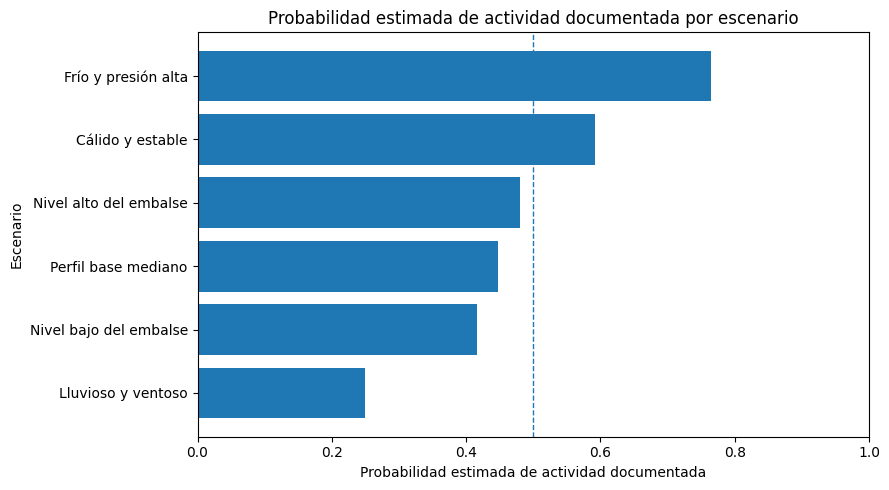

Figura guardada en:
/content/drive/MyDrive/PIDS4jjj2/outputs/scenarios_binary/scenario_probability_barplot.png


In [53]:
fig, ax = plt.subplots(figsize=(9, 5))

plot_df = manual_results_df.sort_values("p_active", ascending=True)

ax.barh(plot_df["scenario"], plot_df["p_active"])
ax.axvline(0.5, linestyle="--", linewidth=1)

ax.set_xlabel("Probabilidad estimada de actividad documentada")
ax.set_ylabel("Escenario")
ax.set_title("Probabilidad estimada de actividad documentada por escenario")
ax.set_xlim(0, 1)

plt.tight_layout()

scenario_bar_path = SCENARIOS_DIR / "scenario_probability_barplot.png"
plt.savefig(scenario_bar_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figura guardada en:")
print(scenario_bar_path)

## Análisis de sensibilidad univariable

Además de los escenarios manuales, se realiza un análisis de sensibilidad modificando una variable ambiental cada vez y manteniendo el resto en su valor base.

Este análisis permite observar qué variables producen mayores cambios en la probabilidad estimada de actividad documentada según el modelo.

In [54]:
def build_one_variable_sensitivity(base_values, feature_name, n_points=30, variation=0.25):
    """
    Genera escenarios variando una sola variable alrededor del valor base.
    """
    base_value = base_values[feature_name]

    if base_value == 0:
        values = np.linspace(-1, 1, n_points)
    else:
        values = np.linspace(
            base_value * (1 - variation),
            base_value * (1 + variation),
            n_points
        )

    rows = []

    for value in values:
        row = base_values.copy()
        row[feature_name] = value
        row["scenario"] = feature_name
        row["varied_feature"] = feature_name
        row["varied_value"] = value
        rows.append(row)

    return pd.DataFrame(rows)


sensitivity_dfs = []

for feature in feature_cols:
    temp_df = build_one_variable_sensitivity(
        base_values=base_values,
        feature_name=feature,
        n_points=30,
        variation=0.30
    )
    sensitivity_dfs.append(temp_df)

sensitivity_df = pd.concat(sensitivity_dfs, ignore_index=True)

sensitivity_results_df = predict_scenarios(
    sensitivity_df,
    model,
    feature_cols
)

sensitivity_results_df.head()

,temp_mean_quarter,precip_sum_quarter,wind_max_mean_quarter,agua_actual_mean_quarter,pressure_msl_mean_quarter,scenario,varied_feature,varied_value,predicted_class,p_active
0,10.199231,125.05,15.623406,88.576923,1016.306522,temp_mean_quarter,temp_mean_quarter,10.199231,active,0.503306
1,10.500686,125.05,15.623406,88.576923,1016.306522,temp_mean_quarter,temp_mean_quarter,10.500686,low,0.499438
2,10.802141,125.05,15.623406,88.576923,1016.306522,temp_mean_quarter,temp_mean_quarter,10.802141,low,0.495571
3,11.103596,125.05,15.623406,88.576923,1016.306522,temp_mean_quarter,temp_mean_quarter,11.103596,low,0.491703
4,11.405051,125.05,15.623406,88.576923,1016.306522,temp_mean_quarter,temp_mean_quarter,11.405051,low,0.487837


## Figura — Curvas de sensibilidad

Las curvas de sensibilidad muestran cómo cambia `p_active` cuando se modifica una variable ambiental y las demás permanecen constantes en el perfil base.

Esta figura ayuda a interpretar la dirección del efecto aprendido por el modelo.

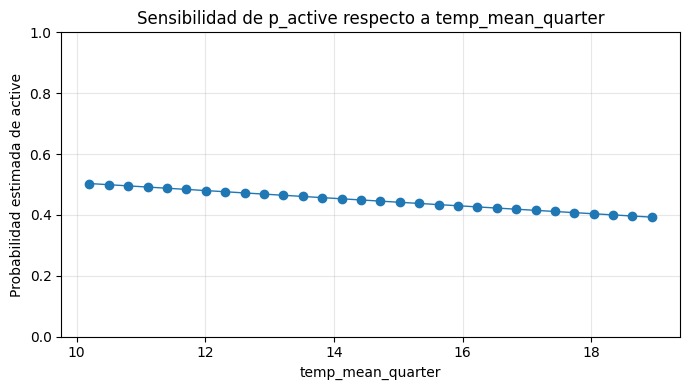

Figura guardada en: /content/drive/MyDrive/PIDS4jjj2/outputs/scenarios_binary/sensitivity_temp_mean_quarter.png


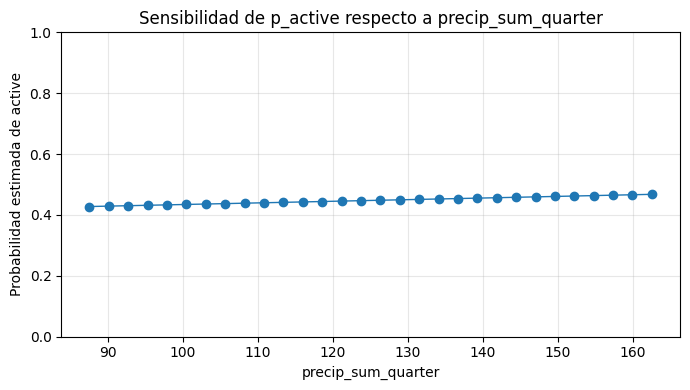

Figura guardada en: /content/drive/MyDrive/PIDS4jjj2/outputs/scenarios_binary/sensitivity_precip_sum_quarter.png


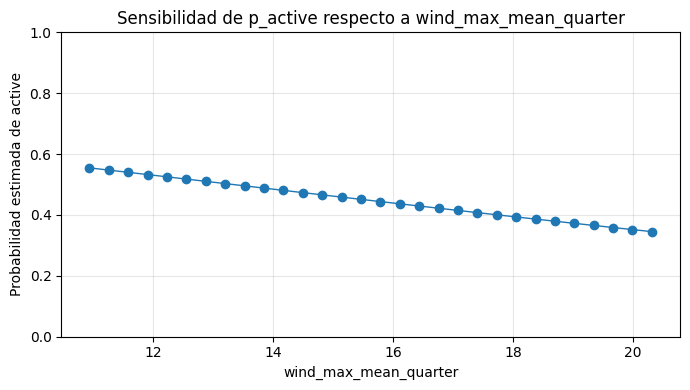

Figura guardada en: /content/drive/MyDrive/PIDS4jjj2/outputs/scenarios_binary/sensitivity_wind_max_mean_quarter.png


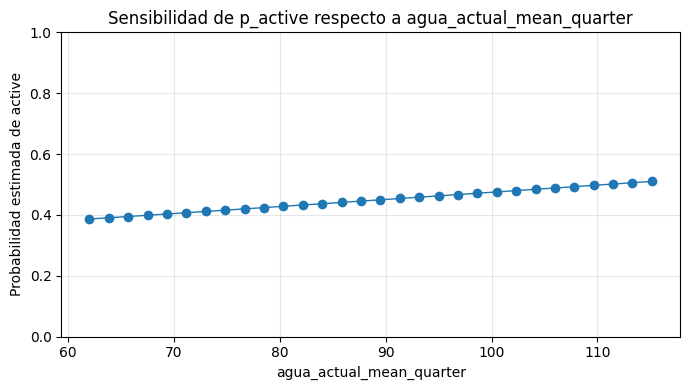

Figura guardada en: /content/drive/MyDrive/PIDS4jjj2/outputs/scenarios_binary/sensitivity_agua_actual_mean_quarter.png


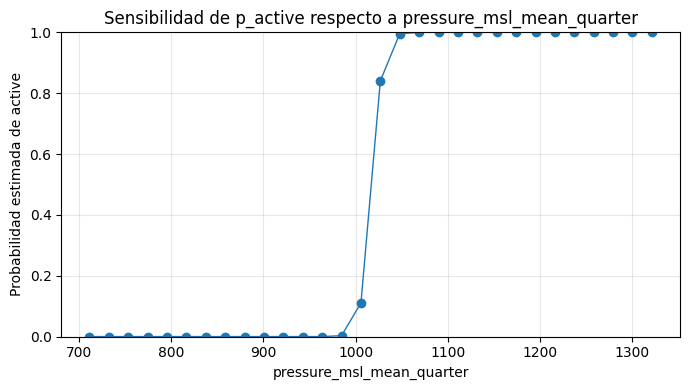

Figura guardada en: /content/drive/MyDrive/PIDS4jjj2/outputs/scenarios_binary/sensitivity_pressure_msl_mean_quarter.png


In [55]:
for feature in feature_cols:
    temp = sensitivity_results_df[
        sensitivity_results_df["varied_feature"] == feature
    ].copy()

    plt.figure(figsize=(7, 4))
    plt.plot(temp["varied_value"], temp["p_active"], marker="o", linewidth=1)

    plt.xlabel(feature)
    plt.ylabel("Probabilidad estimada de active")
    plt.title(f"Sensibilidad de p_active respecto a {feature}")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    fig_path = SCENARIOS_DIR / f"sensitivity_{feature}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")

    plt.show()

    print("Figura guardada en:", fig_path)

## Figura resumen de sensibilidad

Se genera una figura conjunta con la sensibilidad de la probabilidad estimada frente a cada variable ambiental. Esta visualización permite comparar de forma compacta qué variables producen cambios más visibles en la salida del modelo.

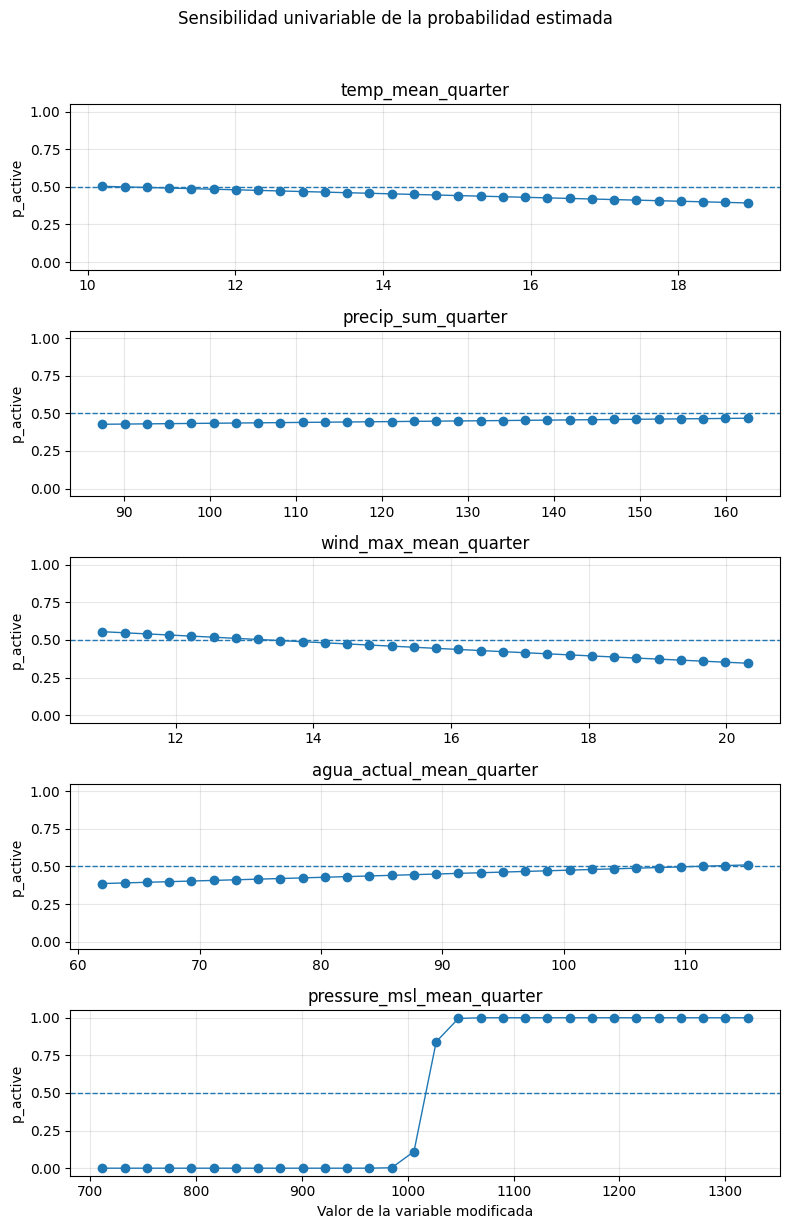

Figura guardada en:
/content/drive/MyDrive/PIDS4jjj2/outputs/scenarios_binary/sensitivity_summary.png


In [56]:
fig, axes = plt.subplots(
    nrows=len(feature_cols),
    ncols=1,
    figsize=(8, 12),
    sharey=True
)

for ax, feature in zip(axes, feature_cols):
    temp = sensitivity_results_df[
        sensitivity_results_df["varied_feature"] == feature
    ].copy()

    ax.plot(temp["varied_value"], temp["p_active"], marker="o", linewidth=1)
    ax.axhline(0.5, linestyle="--", linewidth=1)
    ax.set_title(feature)
    ax.set_ylabel("p_active")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Valor de la variable modificada")

plt.suptitle("Sensibilidad univariable de la probabilidad estimada", y=1.02)
plt.tight_layout()

sensitivity_summary_path = SCENARIOS_DIR / "sensitivity_summary.png"
plt.savefig(sensitivity_summary_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figura guardada en:")
print(sensitivity_summary_path)

## Carga del dataset histórico de modelado

Para construir perfiles de escenarios más realistas, se carga el dataset final de modelado. Este dataset permite calcular percentiles reales de las variables ambientales y perfiles históricos por trimestre del año.

Estos perfiles no representan predicciones meteorológicas futuras, sino aproximaciones orientativas basadas en el comportamiento histórico agregado.

In [57]:
MODEL_DATASET_PATH = ARTIFACTS_DIR / "valmayor_modeling_dataset.parquet"

df_model = pd.read_parquet(MODEL_DATASET_PATH)

print("Shape:", df_model.shape)
print("Columnas disponibles:")
print(df_model.columns.tolist())

display(df_model[["year", "year_quarter"] + feature_cols].head())

Shape: (54, 41)
Columnas disponibles:
['year', 'year_quarter', 'n_videos', 'mean_activity_mentions', 'share_low', 'share_medium', 'share_high', 'share_certainty_high', 'captures_nonnull_mean', 'target_class', 'target_class_id', 'quarter_x', 'temp_mean_quarter', 'temp_max_mean_quarter', 'temp_min_mean_quarter', 'precip_sum_quarter', 'rain_sum_quarter', 'snowfall_sum_quarter', 'wind_max_mean_quarter', 'radiation_sum_quarter', 'eto_sum_quarter', 'quarter_y', 'agua_total_mean_quarter', 'agua_total_min_quarter', 'agua_total_max_quarter', 'agua_total_std_quarter', 'agua_actual_mean_quarter', 'agua_actual_min_quarter', 'agua_actual_max_quarter', 'agua_actual_std_quarter', 'n_obs_embalse_quarter', 'quarter', 'pressure_msl_mean_quarter', 'pressure_msl_min_quarter', 'pressure_msl_max_quarter', 'pressure_msl_std_quarter', 'surface_pressure_mean_quarter', 'surface_pressure_min_quarter', 'surface_pressure_max_quarter', 'surface_pressure_std_quarter', 'n_obs_pressure_quarter']


,year,year_quarter,temp_mean_quarter,precip_sum_quarter,wind_max_mean_quarter,agua_actual_mean_quarter,pressure_msl_mean_quarter
0,2009.0,2009-Q3,23.242391,35.2,13.942391,89.538462,1016.347826
1,2009.0,2009-Q4,9.527174,181.0,14.471739,65.692308,1016.265217
2,2010.0,2010-Q1,4.318889,209.6,15.778889,81.923077,1014.594444
3,2010.0,2010-Q2,14.508791,164.4,13.484615,112.153846,1015.339560
4,2011.0,2011-Q1,5.338889,172.8,13.282222,106.307692,1020.051111


## Construcción de perfiles trimestrales históricos

Para obtener una proyección orientativa de los trimestres restantes de 2026, se construyen perfiles históricos por trimestre del año (`Q1`, `Q2`, `Q3`, `Q4`).

Cada perfil se calcula como la mediana histórica de las variables ambientales utilizadas por el modelo. Esta aproximación permite construir escenarios estacionales sin introducir una variable temporal explícita como `year`.

In [58]:
hist_df = df_model.copy()

hist_df["quarter_only"] = hist_df["year_quarter"].astype(str).str.split("-").str[1]

# Opcional: excluir 2026 para que los perfiles sean puramente históricos
hist_df_for_profiles = hist_df[hist_df["year"] < 2026].copy()

quarter_profiles = (
    hist_df_for_profiles
    .groupby("quarter_only")[feature_cols]
    .median(numeric_only=True)
    .reset_index()
)

quarter_profiles

,quarter_only,temp_mean_quarter,precip_sum_quarter,wind_max_mean_quarter,agua_actual_mean_quarter,pressure_msl_mean_quarter
0,Q1,6.571111,172.8,16.247778,99.461538,1020.051111
1,Q2,16.171429,137.2,16.276923,95.461538,1015.519780
2,Q3,23.669565,43.9,16.545652,90.153846,1015.957609
3,Q4,9.840217,199.0,14.342391,81.076923,1019.333696


## Proyección orientativa para 2026-Q3 y 2026-Q4

A partir de los perfiles históricos trimestrales se generan dos escenarios orientativos para `2026-Q3` y `2026-Q4`.

Estas filas no son observaciones medidas ni predicciones meteorológicas. Son perfiles sintéticos basados en la mediana histórica de cada trimestre del año.

In [59]:
future_2026 = quarter_profiles[
    quarter_profiles["quarter_only"].isin(["Q3", "Q4"])
].copy()

future_2026["year"] = 2026
future_2026["year_quarter"] = future_2026["quarter_only"].apply(lambda q: f"2026-{q}")
future_2026["scenario"] = future_2026["year_quarter"].apply(
    lambda x: f"Perfil histórico orientativo {x}"
)

future_2026 = future_2026[
    ["scenario", "year", "year_quarter", "quarter_only"] + feature_cols
].reset_index(drop=True)

future_2026

,scenario,year,year_quarter,quarter_only,temp_mean_quarter,precip_sum_quarter,wind_max_mean_quarter,agua_actual_mean_quarter,pressure_msl_mean_quarter
0,Perfil histórico orientativo 2026-Q3,2026,2026-Q3,Q3,23.669565,43.9,16.545652,90.153846,1015.957609
1,Perfil histórico orientativo 2026-Q4,2026,2026-Q4,Q4,9.840217,199.0,14.342391,81.076923,1019.333696


## Probabilidad estimada para 2026-Q3 y 2026-Q4

Se aplica el modelo binario a los perfiles orientativos de `2026-Q3` y `2026-Q4`. La salida principal es `p_active`, que representa la probabilidad estimada de actividad documentada según el comportamiento aprendido por el modelo.

In [60]:
future_results_df = predict_scenarios(
    future_2026,
    model,
    feature_cols
)

future_results_df = future_results_df.sort_values("year_quarter").reset_index(drop=True)

future_results_df

,scenario,year,year_quarter,quarter_only,temp_mean_quarter,precip_sum_quarter,wind_max_mean_quarter,agua_actual_mean_quarter,pressure_msl_mean_quarter,predicted_class,p_active
0,Perfil histórico orientativo 2026-Q3,2026,2026-Q3,Q3,23.669565,43.9,16.545652,90.153846,1015.957609,low,0.271782
1,Perfil histórico orientativo 2026-Q4,2026,2026-Q4,Q4,9.840217,199.0,14.342391,81.076923,1019.333696,active,0.685155


## Figura — Proyección orientativa para los trimestres restantes de 2026

La siguiente figura muestra la probabilidad estimada de actividad documentada para los perfiles históricos orientativos de `2026-Q3` y `2026-Q4`.

Esta figura puede utilizarse en la memoria como análisis exploratorio, siempre indicando que no se trata de una predicción operativa.

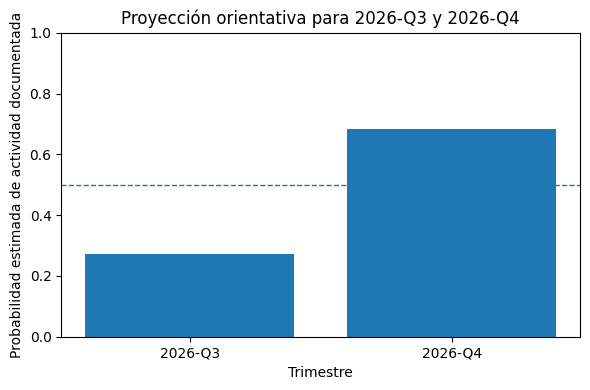

Figura guardada en:
/content/drive/MyDrive/PIDS4jjj2/outputs/scenarios_binary/future_2026_q3_q4_probability.png


In [61]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    future_results_df["year_quarter"],
    future_results_df["p_active"]
)

ax.axhline(0.5, linestyle="--", linewidth=1)

ax.set_ylabel("Probabilidad estimada de actividad documentada")
ax.set_xlabel("Trimestre")
ax.set_title("Proyección orientativa para 2026-Q3 y 2026-Q4")
ax.set_ylim(0, 1)

plt.tight_layout()

future_2026_path = SCENARIOS_DIR / "future_2026_q3_q4_probability.png"
plt.savefig(future_2026_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figura guardada en:")
print(future_2026_path)

## Curva estacional orientativa

Además de los escenarios individuales, se construye una curva estacional orientativa utilizando perfiles históricos por trimestre del año.

Para cada trimestre (`Q1`, `Q2`, `Q3`, `Q4`) se calcula el perfil ambiental mediano a partir del histórico disponible. Después, el modelo estima la probabilidad de actividad documentada (`p_active`) asociada a cada perfil.

Esta curva no debe interpretarse como una predicción temporal real, ya que no utiliza información meteorológica futura. Su objetivo es mostrar cómo responde el modelo ante perfiles ambientales típicos de cada estación.

In [62]:
# Perfil ambiental mediano por trimestre del año

seasonal_profiles = (
    hist_df_for_profiles
    .groupby("quarter_only")[feature_cols]
    .median(numeric_only=True)
    .reset_index()
)

seasonal_profiles["scenario"] = seasonal_profiles["quarter_only"].apply(
    lambda q: f"Perfil estacional histórico {q}"
)

seasonal_profiles = seasonal_profiles[
    ["scenario", "quarter_only"] + feature_cols
]

seasonal_results_df = predict_scenarios(
    seasonal_profiles,
    model,
    feature_cols
)

seasonal_results_df = seasonal_results_df.sort_values("quarter_only").reset_index(drop=True)

seasonal_results_df

,scenario,quarter_only,temp_mean_quarter,precip_sum_quarter,wind_max_mean_quarter,agua_actual_mean_quarter,pressure_msl_mean_quarter,predicted_class,p_active
0,Perfil estacional histórico Q1,Q1,6.571111,172.8,16.247778,99.461538,1020.051111,active,0.734099
1,Perfil estacional histórico Q2,Q2,16.171429,137.2,16.276923,95.461538,1015.519780,low,0.400839
2,Perfil estacional histórico Q3,Q3,23.669565,43.9,16.545652,90.153846,1015.957609,low,0.271782
3,Perfil estacional histórico Q4,Q4,9.840217,199.0,14.342391,81.076923,1019.333696,active,0.685155


## Figura — Probabilidad estimada por trimestre estacional

La siguiente figura resume la probabilidad estimada de actividad documentada para los perfiles ambientales típicos de cada trimestre del año.

Esta visualización permite identificar si el modelo asocia determinados perfiles estacionales con mayor probabilidad de actividad documentada.

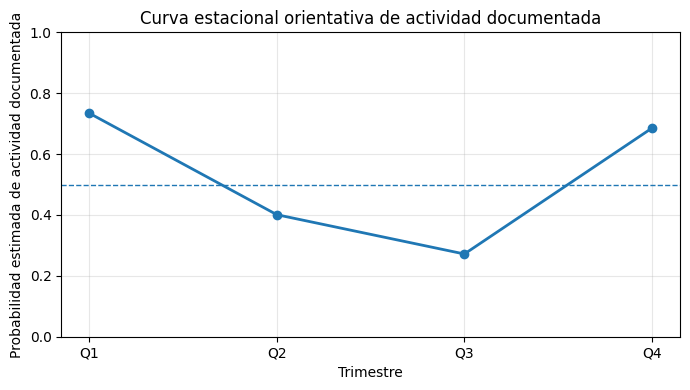

Figura guardada en:
/content/drive/MyDrive/PIDS4jjj2/outputs/scenarios_binary/seasonal_activity_probability_curve.png


In [63]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    seasonal_results_df["quarter_only"],
    seasonal_results_df["p_active"],
    marker="o",
    linewidth=2
)

ax.axhline(0.5, linestyle="--", linewidth=1)

ax.set_xlabel("Trimestre")
ax.set_ylabel("Probabilidad estimada de actividad documentada")
ax.set_title("Curva estacional orientativa de actividad documentada")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)

plt.tight_layout()

seasonal_curve_path = SCENARIOS_DIR / "seasonal_activity_probability_curve.png"
plt.savefig(seasonal_curve_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figura guardada en:")
print(seasonal_curve_path)

## Proyección estacional orientativa a años posteriores

A continuación se repite el patrón estacional histórico para varios años posteriores. Esta representación no incorpora predicciones meteorológicas ni cambios reales futuros: simplemente proyecta los perfiles ambientales típicos de cada trimestre para visualizar cómo sería la respuesta del modelo bajo condiciones estacionales medias.

Por tanto, debe entenderse como una curva de escenarios estacionales, no como forecasting operativo.

In [64]:
future_years = list(range(2026, 2031))

future_seasonal_rows = []

for year in future_years:
    for _, row in seasonal_profiles.iterrows():
        quarter = row["quarter_only"]

        # Opcional: si quieres mantener solo Q3 y Q4 de 2026 porque Q1-Q2 ya han pasado
        if year == 2026 and quarter in ["Q1", "Q2"]:
            continue

        new_row = row.to_dict()
        new_row["year"] = year
        new_row["year_quarter"] = f"{year}-{quarter}"
        new_row["scenario"] = f"Perfil estacional orientativo {year}-{quarter}"

        future_seasonal_rows.append(new_row)

future_seasonal_df = pd.DataFrame(future_seasonal_rows)

future_seasonal_df = future_seasonal_df[
    ["scenario", "year", "year_quarter", "quarter_only"] + feature_cols
]

future_seasonal_results_df = predict_scenarios(
    future_seasonal_df,
    model,
    feature_cols
)

future_seasonal_results_df = future_seasonal_results_df.sort_values(
    ["year", "quarter_only"]
).reset_index(drop=True)

future_seasonal_results_df

,scenario,year,year_quarter,quarter_only,temp_mean_quarter,precip_sum_quarter,wind_max_mean_quarter,agua_actual_mean_quarter,pressure_msl_mean_quarter,predicted_class,p_active
0,Perfil estacional orientativo 2026-Q3,2026,2026-Q3,Q3,23.669565,43.9,16.545652,90.153846,1015.957609,low,0.271782
1,Perfil estacional orientativo 2026-Q4,2026,2026-Q4,Q4,9.840217,199.0,14.342391,81.076923,1019.333696,active,0.685155
2,Perfil estacional orientativo 2027-Q1,2027,2027-Q1,Q1,6.571111,172.8,16.247778,99.461538,1020.051111,active,0.734099
3,Perfil estacional orientativo 2027-Q2,2027,2027-Q2,Q2,16.171429,137.2,16.276923,95.461538,1015.519780,low,0.400839
4,Perfil estacional orientativo 2027-Q3,2027,2027-Q3,Q3,23.669565,43.9,16.545652,90.153846,1015.957609,low,0.271782
5,Perfil estacional orientativo 2027-Q4,2027,2027-Q4,Q4,9.840217,199.0,14.342391,81.076923,1019.333696,active,0.685155
6,Perfil estacional orientativo 2028-Q1,2028,2028-Q1,Q1,6.571111,172.8,16.247778,99.461538,1020.051111,active,0.734099
7,Perfil estacional orientativo 2028-Q2,2028,2028-Q2,Q2,16.171429,137.2,16.276923,95.461538,1015.519780,low,0.400839
8,Perfil estacional orientativo 2028-Q3,2028,2028-Q3,Q3,23.669565,43.9,16.545652,90.153846,1015.957609,low,0.271782
9,Perfil estacional orientativo 2028-Q4,2028,2028-Q4,Q4,9.840217,199.0,14.342391,81.076923,1019.333696,active,0.685155


## Figura — Curva orientativa para años posteriores

La siguiente figura muestra la probabilidad estimada de actividad documentada al repetir perfiles ambientales estacionales históricos en años posteriores.

La curva no representa una predicción real de pesca futura, sino una visualización del comportamiento esperado del modelo ante perfiles ambientales típicos de cada trimestre.

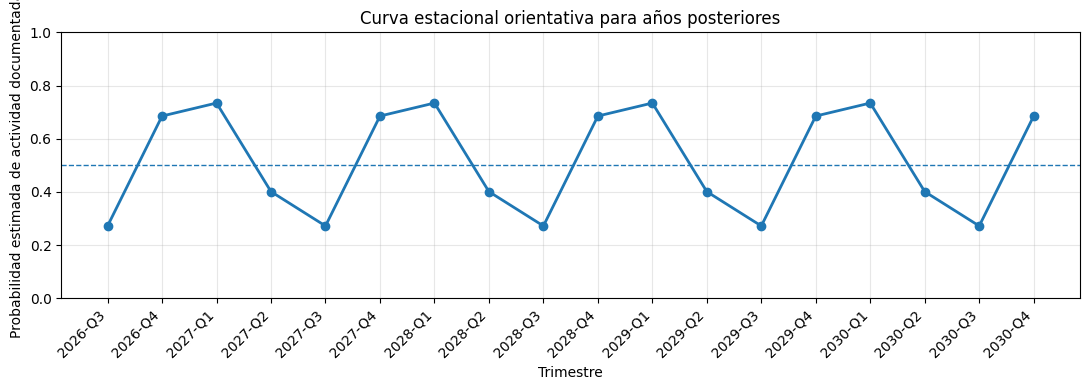

Figura guardada en:
/content/drive/MyDrive/PIDS4jjj2/outputs/scenarios_binary/future_seasonal_activity_curve.png


In [65]:
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(
    future_seasonal_results_df["year_quarter"],
    future_seasonal_results_df["p_active"],
    marker="o",
    linewidth=2
)

ax.axhline(0.5, linestyle="--", linewidth=1)

ax.set_xlabel("Trimestre")
ax.set_ylabel("Probabilidad estimada de actividad documentada")
ax.set_title("Curva estacional orientativa para años posteriores")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

future_seasonal_curve_path = SCENARIOS_DIR / "future_seasonal_activity_curve.png"
plt.savefig(future_seasonal_curve_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figura guardada en:")
print(future_seasonal_curve_path)

## Rango orientativo por trimestre

Para añadir una lectura de incertidumbre exploratoria, se calculan perfiles bajos, medianos y altos por trimestre usando percentiles históricos (`p25`, `p50`, `p75`) de las variables ambientales.

Esto no es un intervalo de confianza estadístico, sino una banda descriptiva que muestra cómo varía la salida del modelo ante condiciones ambientales históricamente bajas o altas para cada trimestre.

In [66]:
seasonal_band_rows = []

for quarter in sorted(hist_df_for_profiles["quarter_only"].dropna().unique()):
    quarter_df = hist_df_for_profiles[
        hist_df_for_profiles["quarter_only"] == quarter
    ]

    for label, q in [
        ("p25", 0.25),
        ("p50", 0.50),
        ("p75", 0.75),
    ]:
        values = quarter_df[feature_cols].quantile(q).to_dict()

        row = {
            "scenario": f"Perfil {label} {quarter}",
            "quarter_only": quarter,
            "profile": label,
            **values,
        }

        seasonal_band_rows.append(row)

seasonal_band_df = pd.DataFrame(seasonal_band_rows)

seasonal_band_results_df = predict_scenarios(
    seasonal_band_df,
    model,
    feature_cols
)

seasonal_band_results_df = seasonal_band_results_df.sort_values(
    ["quarter_only", "profile"]
).reset_index(drop=True)

seasonal_band_results_df

,scenario,quarter_only,profile,temp_mean_quarter,precip_sum_quarter,wind_max_mean_quarter,agua_actual_mean_quarter,pressure_msl_mean_quarter,predicted_class,p_active
0,Perfil p25 Q1,Q1,p25,5.457778,125.45,15.716111,83.730769,1018.826117,active,0.657438
1,Perfil p50 Q1,Q1,p50,6.571111,172.80,16.247778,99.461538,1020.051111,active,0.734099
2,Perfil p75 Q1,Q1,p75,7.556667,227.15,16.729444,103.163462,1022.387778,active,0.816024
3,Perfil p25 Q2,Q2,p25,15.062637,94.80,15.494505,87.615385,1014.648352,low,0.355605
4,Perfil p50 Q2,Q2,p50,16.171429,137.20,16.276923,95.461538,1015.519780,low,0.400839
5,Perfil p75 Q2,Q2,p75,17.080220,175.50,16.989011,111.076923,1015.808791,low,0.442301
6,Perfil p25 Q3,Q3,p25,23.203804,22.10,13.923370,72.807692,1015.375000,low,0.261903
7,Perfil p50 Q3,Q3,p50,23.669565,43.90,16.545652,90.153846,1015.957609,low,0.271782
8,Perfil p75 Q3,Q3,p75,23.991304,98.85,17.246739,97.115385,1016.370109,low,0.308277
9,Perfil p25 Q4,Q4,p25,9.479348,155.10,12.911957,65.692308,1017.941304,active,0.607961


## Figura — Banda descriptiva de escenarios estacionales

La siguiente figura muestra la probabilidad estimada para perfiles bajos, medianos y altos de cada trimestre. La banda no debe interpretarse como incertidumbre predictiva formal, sino como una comparación descriptiva de escenarios ambientales históricos.

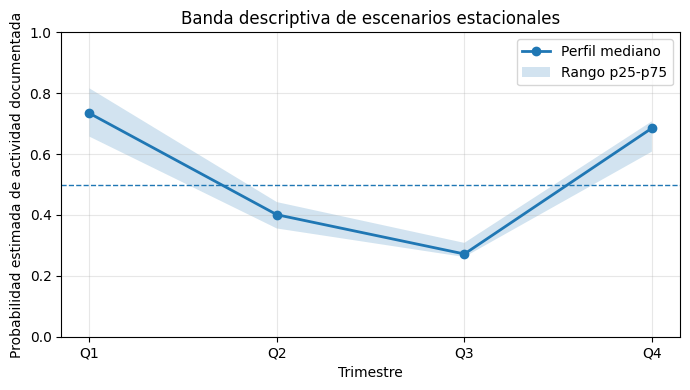

Figura guardada en:
/content/drive/MyDrive/PIDS4jjj2/outputs/scenarios_binary/seasonal_activity_probability_band.png


In [67]:
band_pivot = seasonal_band_results_df.pivot(
    index="quarter_only",
    columns="profile",
    values="p_active"
).reset_index()

band_pivot = band_pivot.sort_values("quarter_only")

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    band_pivot["quarter_only"],
    band_pivot["p50"],
    marker="o",
    linewidth=2,
    label="Perfil mediano"
)

ax.fill_between(
    band_pivot["quarter_only"],
    band_pivot["p25"],
    band_pivot["p75"],
    alpha=0.2,
    label="Rango p25-p75"
)

ax.axhline(0.5, linestyle="--", linewidth=1)

ax.set_xlabel("Trimestre")
ax.set_ylabel("Probabilidad estimada de actividad documentada")
ax.set_title("Banda descriptiva de escenarios estacionales")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

seasonal_band_path = SCENARIOS_DIR / "seasonal_activity_probability_band.png"
plt.savefig(seasonal_band_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figura guardada en:")
print(seasonal_band_path)

In [68]:
# Guardado final de resultados y figuras del notebook de escenarios

SCENARIOS_DIR.mkdir(parents=True, exist_ok=True)

manual_results_path = SCENARIOS_DIR / "manual_scenario_results.csv"
sensitivity_results_path = SCENARIOS_DIR / "sensitivity_results.csv"
future_2026_results_path = SCENARIOS_DIR / "future_2026_q3_q4_results.csv"
seasonal_results_path = SCENARIOS_DIR / "seasonal_profile_results.csv"
future_seasonal_results_path = SCENARIOS_DIR / "future_seasonal_results.csv"
seasonal_band_results_path = SCENARIOS_DIR / "seasonal_band_results.csv"

manual_results_df.to_csv(manual_results_path, index=False, encoding="utf-8")
sensitivity_results_df.to_csv(sensitivity_results_path, index=False, encoding="utf-8")
future_results_df.to_csv(future_2026_results_path, index=False, encoding="utf-8")
seasonal_results_df.to_csv(seasonal_results_path, index=False, encoding="utf-8")
future_seasonal_results_df.to_csv(future_seasonal_results_path, index=False, encoding="utf-8")
seasonal_band_results_df.to_csv(seasonal_band_results_path, index=False, encoding="utf-8")

print("Tablas guardadas:")
print(manual_results_path)
print(sensitivity_results_path)
print(future_2026_results_path)
print(seasonal_results_path)
print(future_seasonal_results_path)
print(seasonal_band_results_path)

print("\nFiguras principales generadas:")
print(scenario_bar_path)
print(sensitivity_summary_path)
print(future_2026_path)
print(seasonal_curve_path)
print(future_seasonal_curve_path)
print(seasonal_band_path)

Tablas guardadas:
/content/drive/MyDrive/PIDS4jjj2/outputs/scenarios_binary/manual_scenario_results.csv
/content/drive/MyDrive/PIDS4jjj2/outputs/scenarios_binary/sensitivity_results.csv
/content/drive/MyDrive/PIDS4jjj2/outputs/scenarios_binary/future_2026_q3_q4_results.csv
/content/drive/MyDrive/PIDS4jjj2/outputs/scenarios_binary/seasonal_profile_results.csv
/content/drive/MyDrive/PIDS4jjj2/outputs/scenarios_binary/future_seasonal_results.csv
/content/drive/MyDrive/PIDS4jjj2/outputs/scenarios_binary/seasonal_band_results.csv

Figuras principales generadas:
/content/drive/MyDrive/PIDS4jjj2/outputs/scenarios_binary/scenario_probability_barplot.png
/content/drive/MyDrive/PIDS4jjj2/outputs/scenarios_binary/sensitivity_summary.png
/content/drive/MyDrive/PIDS4jjj2/outputs/scenarios_binary/future_2026_q3_q4_probability.png
/content/drive/MyDrive/PIDS4jjj2/outputs/scenarios_binary/seasonal_activity_probability_curve.png
/content/drive/MyDrive/PIDS4jjj2/outputs/scenarios_binary/future_seasonal_

## Conclusión del notebook

Este notebook aplica el modelo binario final a diferentes escenarios ambientales relacionados con el embalse de Valmayor. El objetivo no es realizar una predicción operativa de la actividad pesquera, sino analizar cómo responde el modelo ante distintos perfiles de temperatura, precipitación, viento, nivel del embalse y presión atmosférica.

En primer lugar, se han definido escenarios manuales interpretables, como perfiles cálidos y estables, lluviosos y ventosos, o situaciones de mayor y menor nivel del embalse. Estos escenarios permiten observar cómo cambia la probabilidad estimada de actividad documentada (`p_active`) ante combinaciones ambientales concretas.

En segundo lugar, se ha realizado un análisis de sensibilidad univariable. Este análisis permite estudiar el efecto individual de cada variable ambiental manteniendo constantes las demás. Los resultados ayudan a interpretar la dirección de la respuesta del modelo, aunque no deben entenderse como relaciones causales.

Además, se han construido perfiles estacionales históricos por trimestre del año. A partir de estos perfiles se ha generado una curva estacional orientativa y una banda descriptiva basada en percentiles históricos. Estas visualizaciones resumen cómo varía la probabilidad estimada de actividad documentada bajo condiciones ambientales típicas de cada trimestre.

También se han generado perfiles orientativos para los trimestres restantes de 2026 y para años posteriores. Estos perfiles no incorporan previsiones meteorológicas futuras, por lo que no deben interpretarse como forecasting real. Su utilidad es mostrar la respuesta del modelo cuando se repiten perfiles ambientales estacionales históricos.

En conjunto, el notebook proporciona una herramienta exploratoria para interpretar el modelo y analizar escenarios ambientales. Los resultados deben considerarse como apoyo al análisis del comportamiento del modelo, no como predicciones reales de capturas ni de actividad pesquera futura.